# Método do Cotovelo para o Dataset Adult (KMeans)

Este notebook permite analisar o número ideal de clusters para o dataset Adult utilizando o método do cotovelo com KMeans.

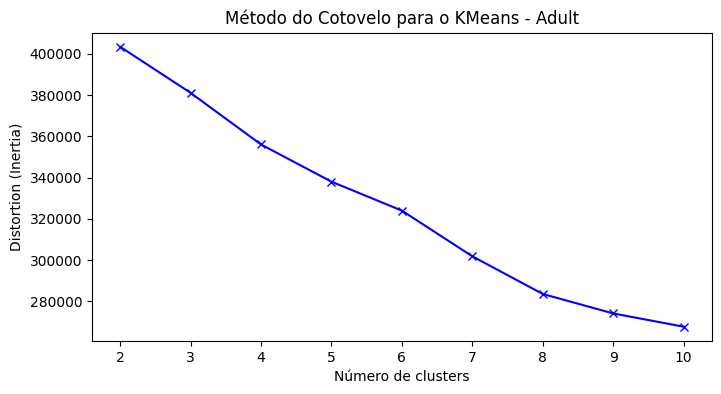

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carregamento e pré-processamento do dataset Adult
adult_df = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df = adult_df.dropna()
for col in adult_df.select_dtypes(include='object').columns:
    adult_df[col] = LabelEncoder().fit_transform(adult_df[col].astype(str))
X = adult_df.drop('income', axis=1).values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Método do cotovelo
K = range(2, 11)
distortions = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Método do Cotovelo para o KMeans - Adult')
plt.savefig('img/kmeans_adult_elbow.png')
plt.show()